In [4]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from celluloid import Camera
from IPython.display import HTML
from IPython.display import display

In [16]:
t, n = sp.symbols("t n")
xp = sp.Function("x'")
yp = sp.Function("y'")
display(xp(t), yp(t), t, n)


x'(t)

y'(t)

t

n

In [19]:
x = xp(t) * sp.cos(n*t) - yp(t) * sp.sin(n*t)
y = xp(t) * sp.sin(n*t) + yp(t) * sp.cos(n*t)
display(x, y)

x'(t)*cos(n*t) - y'(t)*sin(n*t)

x'(t)*sin(n*t) + y'(t)*cos(n*t)

In [20]:
x_punto = sp.diff(x, t)
y_punto = sp.diff(y, t)
display(x_punto, y_punto)


-n*x'(t)*sin(n*t) - n*y'(t)*cos(n*t) - sin(n*t)*Derivative(y'(t), t) + cos(n*t)*Derivative(x'(t), t)

n*x'(t)*cos(n*t) - n*y'(t)*sin(n*t) + sin(n*t)*Derivative(x'(t), t) + cos(n*t)*Derivative(y'(t), t)

In [26]:
#velocidad al cuadrado
v_cuadrado = sp.expand(x_punto**2 + y_punto**2)
display(v_cuadrado)

n**2*x'(t)**2*sin(n*t)**2 + n**2*x'(t)**2*cos(n*t)**2 + n**2*y'(t)**2*sin(n*t)**2 + n**2*y'(t)**2*cos(n*t)**2 + 2*n*x'(t)*sin(n*t)**2*Derivative(y'(t), t) + 2*n*x'(t)*cos(n*t)**2*Derivative(y'(t), t) - 2*n*y'(t)*sin(n*t)**2*Derivative(x'(t), t) - 2*n*y'(t)*cos(n*t)**2*Derivative(x'(t), t) + sin(n*t)**2*Derivative(x'(t), t)**2 + sin(n*t)**2*Derivative(y'(t), t)**2 + cos(n*t)**2*Derivative(x'(t), t)**2 + cos(n*t)**2*Derivative(y'(t), t)**2

In [27]:
#reducción de términos
v_cuadrado_reducida = sp.simplify(v_cuadrado)
display(v_cuadrado_reducida)

n**2*x'(t)**2 + n**2*y'(t)**2 + 2*n*x'(t)*Derivative(y'(t), t) - 2*n*y'(t)*Derivative(x'(t), t) + Derivative(x'(t), t)**2 + Derivative(y'(t), t)**2

In [62]:
#Ecuaciones del CR3BP
def edm_crtbp(t, Ys,alpha):
    x, y, z, vx, vy, vz = Ys
    # varibles auxiliares
    x1 = -alpha  #posición del cuerpo 1
    x2 = 1 - alpha  #posición del cuerpo 2
    r1 = ((x-x1)**2 + (y)**2 + (z)**2)
    r2 = ((x-x2)**2 + (y)**2 + (z)**2)

    #ecuaciones
    dx_dt = vx
    dy_dt = vy
    dz_dt = vz
    dvx_dt = 2*vy + x - (1-alpha)/r1**3 * (x-x1) - alpha/r2**3 * (x-x2)
    dvy_dt = -2*vx + y - (1-alpha)/r1**3 * (y) - alpha/r2**3 * (y)
    dvz_dt = -(1-alpha)/r1**3 * (z) - alpha/r2**3 *z
    return [dx_dt, dy_dt, dz_dt, dvx_dt, dvy_dt, dvz_dt]



In [63]:
edm_crtbp(1, [1,2,3,4,5,6], 1)

[4, 5, 6, 10.999635568513119, -6.0007288629737605, -0.0010932944606413995]

In [64]:
from scipy.integrate import solve_ivp

In [81]:
import numpy as np

alpha = 0.3
ts = np.linspace(0, 10, 1000)
Ys0 = [2, 0, 0, 0, 0, 0]

sol = solve_ivp(edm_crtbp, [ts[0], ts[-1]], Ys0,  t_eval=ts,args=(alpha,),    method="Radau")

In [82]:
xs = sol.y[0]
ys = sol.y[1]
zs = sol.y[2]
vxs = sol.y[3]
vys = sol.y[4]
vzs = sol.y[5]

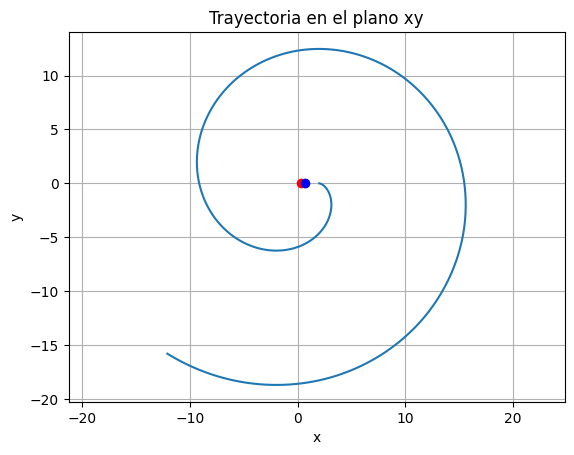

In [84]:
plt.plot(xs, ys)
plt.plot(alpha, 0, "ro")  # Cuerpo 1
plt.plot(1-alpha, 0, "bo")  # Cuerpo 2
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trayectoria en el plano xy")
plt.grid()
plt.axis("equal")
plt.show()
